# MAST pulse

Loads the mesh built by `MAST_mesh_generator.ipynb`, builds seed equilibria from the EFIT reconstruction of a shot, and runs the TokaMaker+TORAX coupling on it. First basic test of a pulse.

In [1]:
# campaigns M5-M9, 2004-2013
import numpy as np
import requests
import xarray as xr
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt

BASE_URL = 'https://mastapp.site'

In [2]:
def openShotGroup(shotId, group, level=1):
    """
    Opens a diagnostic group (efm, ayc, anb, summary, etc) for a shot,
    download of pulse only happen upon a read
    """
    path = f'json/shots/{shotId}' if level == 1 else f'json/level2/shots/{shotId}'
    try:
        response = requests.get(f'{BASE_URL}/{path}')
        response.raise_for_status()
        shot = response.json()
        shotUrl = shot['url'].replace('s3:/', shot['endpoint_url'])
        return xr.open_zarr(shotUrl, group=group)
    except requests.RequestException as e:
        print(f'failed to fetch shot {shotId}: {e}')
        return None

## Load the mesh into TokaMaker

In [3]:
import os
import sys

tokamaker_python_path = os.getenv('OFT_ROOTPATH')
if tokamaker_python_path is not None:
    sys.path.append(os.path.join(tokamaker_python_path, 'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh

shot_id = 30342

myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

mesh_pts, mesh_lc, mesh_reg, coil_dict, cond_dict = load_gs_mesh('MAST_info/MAST_mesh.h5')
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict, coil_dict=coil_dict)

#----------------------------------------------
             ____  ____________
            / __ \/ ____/_  __/
           / / / / /_    / /
          / /_/ / __/   / /
          \____/_/     /_/

Release version:  v26.6

Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2

Linear Algebra backend: native

#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.376E+01
    # of points  =   15166
    # of edges   =   45356
    # of cells   =   30191
    # of boundary points =     139
    # of boundary edges  =     139
    # of boundary cells  =     139
  Resolution statistics:
    hmin =  1.000E-04
    hrms =  3.486E-02
    hmax =  1.673E-01
  Surface grounded at vertex    3336



## Shot data

In [4]:
efm = openShotGroup(shot_id, 'efm', level=1).load()
validTimes = efm['time'].values[~np.isnan(efm['plasma_current_c'].values)]

# EFIT reconstruction only between startup and ramp down, poloidal beta < 0 and li > 2 when plasma is small
efmReliable = (efm['betap'].sel(time=validTimes).values > 0) & (efm['li'].sel(time=validTimes).values < 2.0)

# Longest stretch of reliable slices
reliableTimes = validTimes[efmReliable]
reliableRuns = np.split(reliableTimes, np.where(np.diff(reliableTimes) > 2.5 * np.median(np.diff(validTimes)))[0] + 1)
pulseWindow = max(reliableRuns, key=lambda run: run[-1] - run[0])
tPulseStart = float(pulseWindow[0])
tPulseEnd = float(pulseWindow[-1])
refTime = tPulseStart
equilibrium = efm.sel(time=refTime, method='nearest')

ayc = openShotGroup(shot_id, 'ayc', level=1)[['te', 'ne', 'radius']].load()
teValidTimeMask = ~np.isnan(ayc['te'].values).all(axis=1)
thomsonValidTimes = ayc['time'].values[teValidTimeMask]
thomsonRefTime = float(thomsonValidTimes[np.argmin(np.abs(thomsonValidTimes - refTime))])

## Set input parameters

In [5]:
inputConstants = {
    # Fraction of injected gas that fuels confined plasma
    'gasFuelingEfficiency': 0.02,
    # Edge Te and Ti in keV at the last surface
    'edgeTe': 0.049,
    # Edge density as a fraction of the Greenwald density
    'edgeDensityFraction': 0.12,
    'Zeff': 1.7,
}

In [6]:
def buildGeqdsk(eq):
    """
    Builds a dict matching read_eqdsk()'s keys from an efm equilibrium slice.
    """
    validCols = ~np.isnan(eq['psirz'].values).any(axis=0)
    gridR, gridZ = eq['gridr'].values, eq['gridz'].values
    lcfsR, lcfsZ = eq['lcfs_r'].values, eq['lcfs_z'].values
    lcfsValid = ~np.isnan(lcfsR) & ~np.isnan(lcfsZ)
    return {
        'nr': len(gridR),
        'nz': len(gridZ),
        'rdim': float(gridR.max() - gridR.min()),
        'zdim': float(gridZ.max() - gridZ.min()),
        'rleft': float(gridR.min()),
        'zmid': float((gridZ.max() + gridZ.min()) / 2.0),
        'rcentr': float(eq['rvtor']),
        'bcentr': float(eq['bvac_val']),
        'raxis': float(eq['magnetic_axis_r']),
        'zaxis': float(eq['magnetic_axis_z']),
        'psimag': float(eq['psi_axis']),
        'psibry': float(eq['psi_boundary']),
        'ip': float(eq['plasma_current_c']),
        'fpol': eq['fpsi_c'].values,
        'pres': eq['ppsi_c'].values,
        'ffprim': eq['ffprime'].values,
        'pprime': eq['pprime'].values,
        'psirz': eq['psirz'].values[:, validCols],
        'qpsi': eq['qpsi_c'].values,
        'rzout': np.column_stack([lcfsR[lcfsValid], lcfsZ[lcfsValid]]),
        'rzlim': np.column_stack([eq['limiterr'].values, eq['limiterz'].values]),
    }

def psiNormAtMidplane(rQuery, eq):
    """
    Maps real-space midplane R to normalized poloidal flux using the cleaned psirz grid
    """
    validCols = ~np.isnan(eq['psirz'].values).any(axis=0)
    gridR, gridZ = eq['gridr'].values, eq['gridz'].values
    psirzClean = eq['psirz'].values[:, validCols]
    interp = RegularGridInterpolator((gridZ, gridR), psirzClean, bounds_error=False, fill_value=None)
    # Thomson chords at Z=0
    psi = interp(np.column_stack([np.zeros_like(rQuery), rQuery]))
    return (psi - float(eq['psi_axis'])) / (float(eq['psi_boundary']) - float(eq['psi_axis']))

def rhoTorNormFromPsiNorm(psiNormQuery, eq, lastSurface=1.0):
    """
    rho_tor_norm = sqrt(enclosed toroidal flux / toroidal flux inside lastSurface), lastSurface is the psi_norm of the outer surface
    """
    psiNorm65 = eq['psi_norm'].values
    q = eq['qpsi_c'].values
    torFlux = np.concatenate([[0.0], np.cumsum(0.5 * (q[1:] + q[:-1]) * np.diff(psiNorm65))])
    torFluxNorm = torFlux / np.interp(lastSurface, psiNorm65, torFlux)
    return np.interp(np.clip(psiNormQuery, 0, 1), psiNorm65, torFluxNorm) ** 0.5

def mapThomsonToRho(shotId, refTime, eq, lastSurface=1.0):
    thomson = openShotGroup(shotId, 'ayc', level=1).sel(time=refTime, method='nearest')
    r, te, ne = thomson['radius'].values, thomson['te'].values, thomson['ne'].values
    valid = ~np.isnan(r) & ~np.isnan(te) & ~np.isnan(ne)
    rho = rhoTorNormFromPsiNorm(psiNormAtMidplane(r[valid], eq), eq, lastSurface)
    return rho, te[valid], ne[valid]

def gasPuffRate(shotId, coarseDt=0.01):
    """
    Need a particle rate for set_fueling. gas_injection only gives a cumulative
    injected count, resample onto a coarser time grid before differentiating.
    """
    ds = openShotGroup(shotId, 'gas_injection', level=2)
    t, total = ds['time'].values, ds['total_injected'].values
    tCoarse = np.arange(t.min(), t.max(), coarseDt)
    totalCoarse = np.interp(tCoarse, t, total)
    rateCoarse = np.clip(np.gradient(totalCoarse, tCoarse), 0, None)
    return dict(zip(tCoarse.tolist(), rateCoarse.tolist()))

def buildGeqdsk(eq):
    """
    Builds a dict matching read_eqdsk()'s keys from an efm equilibrium slice.
    """
    validCols = ~np.isnan(eq['psirz'].values).any(axis=0)
    gridR, gridZ = eq['gridr'].values, eq['gridz'].values
    lcfsR, lcfsZ = eq['lcfs_r'].values, eq['lcfs_z'].values
    lcfsValid = ~np.isnan(lcfsR) & ~np.isnan(lcfsZ)
    return {
        'nr': len(gridR),
        'nz': len(gridZ),
        'rdim': float(gridR.max() - gridR.min()),
        'zdim': float(gridZ.max() - gridZ.min()),
        'rleft': float(gridR.min()),
        'zmid': float((gridZ.max() + gridZ.min()) / 2.0),
        'rcentr': float(eq['rvtor']),
        'bcentr': float(eq['bvac_val']),
        'raxis': float(eq['magnetic_axis_r']),
        'zaxis': float(eq['magnetic_axis_z']),
        'psimag': float(eq['psi_axis']),
        'psibry': float(eq['psi_boundary']),
        'ip': float(eq['plasma_current_c']),
        'fpol': eq['fpsi_c'].values,
        'pres': eq['ppsi_c'].values,
        'ffprim': eq['ffprime'].values,
        'pprime': eq['pprime'].values,
        'psirz': eq['psirz'].values[:, validCols],
        'qpsi': eq['qpsi_c'].values,
        'rzout': np.column_stack([lcfsR[lcfsValid], lcfsZ[lcfsValid]]),
        'rzlim': np.column_stack([eq['limiterr'].values, eq['limiterz'].values]),
    }


In [7]:
F0 = float(equilibrium['rvtor'] * equilibrium['bvac_val'])
mygs.setup(order=2, F0=F0)
# Max 100 solver iterations per equilibrium
mygs.settings.maxits = 100


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 
 Inverting real matrix
   Time =    1.0880000000000000E-003


## Seed equilibria

In [8]:
from OpenFUSIONToolkit.TokaMaker.pulse_design import TokaMaker_TORAX

# Seed equilibria, evenly spaced through window
seedTimes = [float(t) for t in np.linspace(tPulseStart, tPulseEnd, 5)]
mygs.set_coil_bounds({name: [-1.0e7, 1.0e7] for name in mygs.coil_sets})  # Loose bounds, not real coil limits

In [9]:
# Generate and save one seed eqdsk per seed time
seedFiles = []
channelToCoilSet = {
    'SOL': 'SOL', 'P2IL FEED': 'P2_INNER_LOWER', 'P2IU FEED': 'P2_INNER_UPPER',
    'P2OL FEED': 'P2_OUTER_LOWER', 'P2OU FEED': 'P2_OUTER_UPPER',
    'P3L FEED': 'P3_LOWER', 'P3U FEED': 'P3_UPPER',
    'P4L FEED': 'P4_LOWER', 'P4U FEED': 'P4_UPPER',
    'P5L FEED': 'P5_LOWER', 'P5U FEED': 'P5_UPPER',
    'P6L': 'P6_LOWER', 'P6U': 'P6_UPPER',
}
# Send seeds, logs, and TORAX outputs to folder
runDir = os.path.join(os.getcwd(), 'pulse_outputs') if os.path.basename(os.getcwd()) != 'pulse_outputs' else os.getcwd()
os.makedirs(os.path.join(runDir, 'seeds'), exist_ok=True)
os.chdir(runDir)

# Same PF current record for every seed time, get once
pfActiveCurrents = openShotGroup(shot_id, 'pf_active', level=2)

for i, seedTime in enumerate(seedTimes):
    seedEq = efm.sel(time=seedTime, method='nearest')
    seedGeqdsk = buildGeqdsk(seedEq)
    seedGeqdsk['pres'] = -seedGeqdsk['pres']

    regTerms = []
    for channelName, coilSetName in channelToCoilSet.items():
        realCurrentAmps = float(pfActiveCurrents['coil_current'].sel(current_channel=channelName).sel(time=seedTime, method='nearest'))
        netTurns = mygs.coil_sets[coilSetName]['net_turns']
        regTerms.append(mygs.coil_reg_term({coilSetName: 1.0}, target=realCurrentAmps * netTurns, weight=1.0e-2))
    mygs.set_coil_reg(reg_terms=regTerms)

    mygs.set_targets(Ip=abs(seedGeqdsk['ip']), pax=abs(seedGeqdsk['pres'][0]))
    # Set boundary flux to EFIT value so seed has physical absolute flux
    mygs.set_flux(seedGeqdsk['rzout'], np.full(len(seedGeqdsk['rzout']), float(seedEq['psi_boundary'])), weights=np.full(len(seedGeqdsk['rzout']), 10.0))

    rzout = seedGeqdsk['rzout']
    r0 = float(seedEq['magnetic_axis_r'])
    z0 = float(seedEq['magnetic_axis_z'])
    a = float((rzout[:, 0].max() - rzout[:, 0].min()) / 2.0)
    kappa = float((rzout[:, 1].max() - rzout[:, 1].min()) / (2.0 * a))
    mygs.init_psi(r0=r0, z0=z0, a=a, kappa=kappa, delta=0.0)
    mygs.solve()

    seedPath = f'seeds/seed_{i}.eqdsk'
    mygs.save_eqdsk(seedPath, cocos=2)  # save_eqdsk defaults to cocos=7, TokaMaker_TORAX assumes cocos=2 internally
    seedFiles.append(seedPath)

/var/folders/0c/497qwkps0n92lm8mgp_t18800000gn/T/ipykernel_61064/456588484.py:33: DeprecationWarning: `set_flux()` is deprecated, use `set_psi_constraints()` instead. This function will be removed in a future version.
  mygs.set_flux(seedGeqdsk['rzout'], np.full(len(seedGeqdsk['rzout']), float(seedEq['psi_boundary'])), weights=np.full(len(seedGeqdsk['rzout']), 10.0))


Starting non-linear GS solver
     1  9.6826E-01  6.3235E-02  8.3369E-03  8.5025E-01  3.2845E-03 -0.0000E+00
     2  1.0636E+00  4.3064E-02  1.3249E-02  8.3742E-01  3.1819E-03 -0.0000E+00
     3  1.0907E+00  3.9519E-02  8.1931E-03  8.3144E-01  3.1620E-03 -0.0000E+00
     4  1.1003E+00  3.8600E-02  4.3316E-03  8.2858E-01  3.2383E-03 -0.0000E+00
     5  1.1040E+00  3.8324E-02  2.1695E-03  8.2720E-01  3.2813E-03 -0.0000E+00
     6  1.1054E+00  3.8232E-02  1.0612E-03  8.2655E-01  3.3065E-03 -0.0000E+00
     7  1.1059E+00  3.8200E-02  5.1164E-04  8.2623E-01  3.3216E-03 -0.0000E+00
     8  1.1061E+00  3.8188E-02  2.4448E-04  8.2608E-01  3.3308E-03 -0.0000E+00
     9  1.1062E+00  3.8184E-02  1.1622E-04  8.2601E-01  3.3364E-03 -0.0000E+00
    10  1.1062E+00  3.8182E-02  5.5076E-05  8.2597E-01  3.3398E-03 -0.0000E+00
    11  1.1063E+00  3.8181E-02  2.6092E-05  8.2596E-01  3.3419E-03 -0.0000E+00
    12  1.1063E+00  3.8181E-02  1.2405E-05  8.2595E-01  3.3432E-03 -0.0000E+00
    13  1.1063E+00  3.

In [10]:
# TORAX cant build flux surface geometry to separatrix of diverted plasmas, use largest last surface factor it accepts
import copy
import torax
from OpenFUSIONToolkit.TokaMaker.pulse_design import BASE_CONFIG

lastSurface = None
for factor in (0.95, 0.9, 0.85):
    try:
        for seedFile in seedFiles:
            geometryCheck = copy.deepcopy(BASE_CONFIG)
            geometryCheck['geometry'] = {'geometry_type': 'eqdsk', 'geometry_directory': os.getcwd(), 'last_surface_factor': factor, 'Ip_from_parameters': False, 'geometry_file': seedFile, 'cocos': 2}
            torax.ToraxConfig.from_dict(geometryCheck)
        lastSurface = factor
        break
    except Exception:
        continue
if lastSurface is None:
    raise ValueError('TORAX rejects the seed equilibria at every last surface factor tried')

## Initial profiles and edge conditions

In [11]:
# Initial kinetic profiles, Te/ne from the first Thomson slice in the window
rhoInit, teInit, neInit = mapThomsonToRho(shot_id, thomsonRefTime, equilibrium, lastSurface)

gasPuffSTotal = gasPuffRate(shot_id)

# Edge conditions from constants, density is fixed fraction of Greenwald density from Ip and EFIT minor radius
tEfm = validTimes[(validTimes >= tPulseStart) & (validTimes <= tPulseEnd)]
aMinor = np.array([(np.nanmax(efm.sel(time=t)['lcfs_r'].values) - np.nanmin(efm.sel(time=t)['lcfs_r'].values)) / 2.0 for t in tEfm])
ipEfm = np.abs(efm['plasma_current_c'].sel(time=tEfm).values)
greenwaldDensity = ipEfm / 1e6 / (np.pi * aMinor ** 2) * 1e20
edgeTeBc = {float(t): inputConstants['edgeTe'] for t in tEfm}
edgeNeBc = {float(t): float(inputConstants['edgeDensityFraction'] * n) for t, n in zip(tEfm, greenwaldDensity)}

## Set up full pulse with tmtx

In [12]:
# Build the coupled object
tmtx = TokaMaker_TORAX(
    t_init=tPulseStart,
    t_final=tPulseEnd,
    eqtimes=seedTimes,
    g_eqdsk_arr=seedFiles,
    tokamaker_obj=mygs,
    tx_dt=0.005,  # MAST pulses run ~0.5s
    tm_times=list(np.linspace(tPulseStart, tPulseEnd, 20)),
    last_surface_factor=lastSurface,
)

# Use the Sauter bootstrap model and low sensitivity sawtooth trigger
tmtx.load_TORAX_config({
    'neoclassical': {'bootstrap_current': {'model_name': 'sauter'}, 'transport': {'model_name': 'angioni_sauter'}},
    'mhd': {'sawtooth': {'trigger_model': {'model_name': 'simple', 's_critical': 1.0}}},
})

In [13]:
# Ip and gas puff, no auxiliary heating for Ohmic shot
ipTrajectory = {float(t): abs(float(i)) for t, i in zip(efm['time'].values[~np.isnan(efm['plasma_current_c'].values)], efm['plasma_current_c'].values[~np.isnan(efm['plasma_current_c'].values)])}
tmtx.set_Ip(ipTrajectory)

# Gas puff scaled by fueling efficiency
tmtx.set_fueling(gas_puff_S_total={t: inputConstants['gasFuelingEfficiency'] * rate for t, rate in gasPuffSTotal.items()}, gas_puff_decay_length=0.05)

In [14]:
# Drop channels outside the last surface where rho > 1
insidePlasma = rhoInit < 1.0
sortOrder = np.argsort(rhoInit[insidePlasma])
rhoSorted = rhoInit[insidePlasma][sortOrder]
# Convert Te to keV
teSorted = teInit[insidePlasma][sortOrder] / 1000.0
neSorted = neInit[insidePlasma][sortOrder]

# Running median to reduce Thomson channel noise
rhoNodes = np.linspace(0.0, 1.0, 11)
def runningMedian(vals, halfWidth=0.1):
    return np.array([np.median(vals[np.abs(rhoSorted - x) <= halfWidth]) if np.any(np.abs(rhoSorted - x) <= halfWidth) else np.nan for x in rhoNodes])
teNodes = runningMedian(teSorted)
neNodes = runningMedian(neSorted)
covered = ~np.isnan(teNodes)
rhoNodes, teNodes, neNodes = rhoNodes[covered], teNodes[covered], neNodes[covered]
neProfile = {0.0: {float(r): float(n) for r, n in zip(rhoNodes, neNodes)}}
teProfile = {0.0: {float(r): float(t) for r, t in zip(rhoNodes, teNodes)}}
# Edge values at every time from the constants
tmtx.set_ne(neProfile, right_bc=edgeNeBc)
tmtx.set_Te(teProfile, right_bc=edgeTeBc)

# Ohmic shot has no CXRS Ti, set Ti = Te to start and at the edge
tmtx.set_Ti(teProfile, right_bc=edgeTeBc)

In [18]:
# carbon impurity, Deuterium only
tmtx.set_plasma_composition(main_ion={'D': 1.0}, Zeff=inputConstants['Zeff'], impurity='C')  # MAST is deuterium only, no tritium

tmtx.set_evolve(density=True, Ti=True, Te=True, current=True)
tmtx.set_TokaMaker_coil_reg()  # defaults to +-45 MA-turns per coil

tmtx.fly(run_name='mast_basic_test', output_mode='minimal', max_loop=2)

  Log file: /Users/d22fish/Documents/7FusionResearch/Software/Research/pulse_outputs/TokaMaker_TORAX_log_mast_basic_test_2026-09-30_020000.log

 TokaMaker_TORAX  
 run_name = mast_basic_test | t=[0.1, 0.5] s | 20 timepoints | dt=0.005 s | max_loop=2

  Initial TORAX relax


Simulating (t=0.16000): 100%|██████████| 100/100 [00:00<00:00, 1930.06it/s]


  Loop 1


  TORAX: running simulation...


Simulating (t=0.51000): 100%|██████████| 100/100 [00:01<00:00, 71.20it/s]


...

  TokaMaker: 20/20 solved (cflux=0.2894 Wb)
	TM summary: 20/20 solved. Levels: analytic: 2, ped_smoothing: 5, raw tx profs: 13.
  Loop 1 result: conv_err=0.000% | TX-TM diff=0.3853% | cflux_TX=0.2905 Wb | cflux_TM=0.2894 Wb

  Loop 2
  TORAX: running simulation...


Simulating (t=0.51000): 100%|██████████| 100/100 [00:01<00:00, 71.42it/s]


  TORAX: done (cflux=0.2797 Wb)
  TokaMaker: solving 20 equilibria...


  TM loop 2: 100%|██████████| 20/20 [01:42<00:00,  5.12s/solve], t=0.51s OK(L0)


  TokaMaker: 20/20 solved (cflux=0.2797 Wb)
	TM summary: 20/20 solved. Levels: analytic: 2, raw tx profs: 18.
  Loop 2 result: conv_err=3.722% | TX-TM diff=0.0121% | cflux_TX=0.2797 Wb | cflux_TM=0.2797 Wb

  Max loop index (2) reached (err=3.722%)

  Loop   cflux TX [Wb]    cflux TM [Wb]    TX-TM diff %  
  ----------------------------------------------------
  1      0.2905           0.2894           0.3853        
  2      0.2797           0.2797           0.0121        
  Total sim time: 4m 57.6s
  Outputs saved to: ./TokaMaker_TORAX_outputs/mast_basic_test_2026-09-30_020000
  Log file: /Users/d22fish/Documents/7FusionResearch/Software/Research/pulse_outputs/TokaMaker_TORAX_log_mast_basic_test_2026-09-30_020000.log



  TokaMaker_TORAX Physics Summary
  Q_max                           0
  Q_max_time                      0.06
  Q_flattop_avg                   0
  E_fusion_total_MJ               0
  beta_N_max                      0.831
  H98_max                         1.749
  H98_flattop_avg                 0.945
  T_e_core_max_keV                1.146
  T_i_core_max_keV                0.4182
  n_e_line_avg_max                9.896e+18
  f_GW_max                        0.2799
  flux_consumed_Wb                0.2797
  P_fusion_max_MW                 0
  P_ohmic_max_MW                  3.814
  l_i_flattop_avg                 0.624
  vloop_tx_flattop_avg_V          0.5763



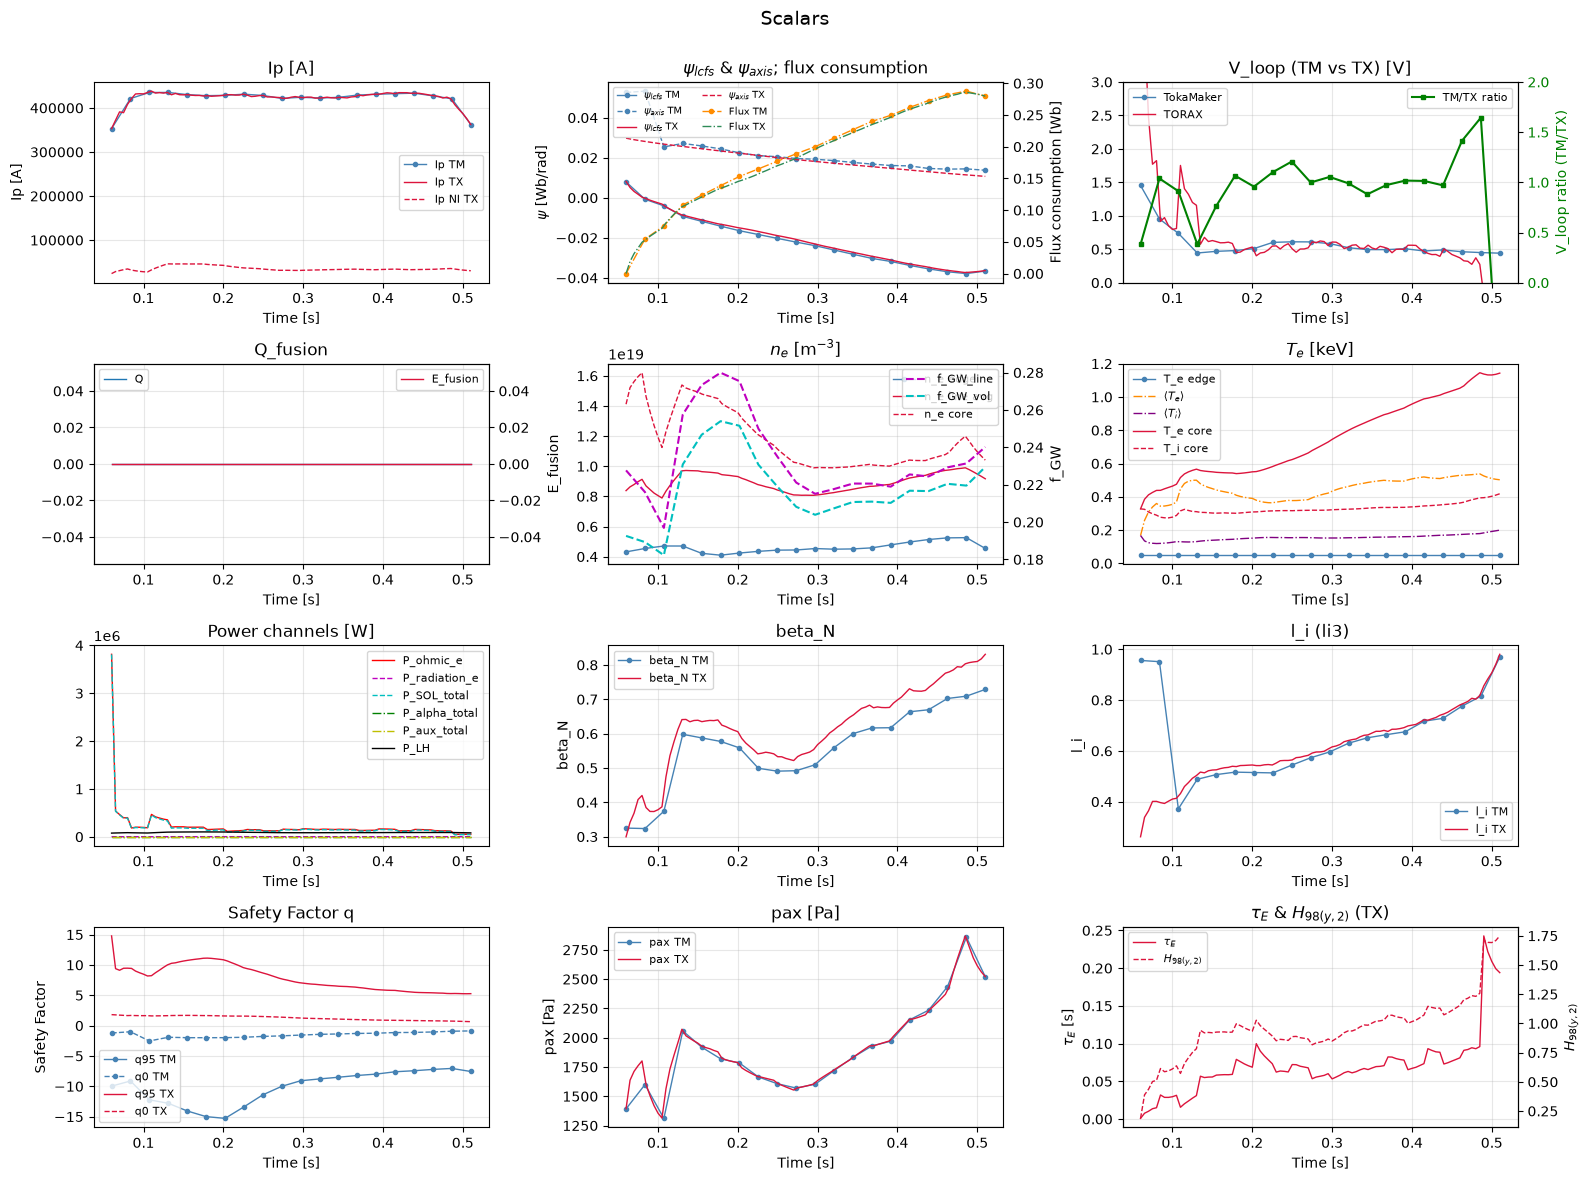

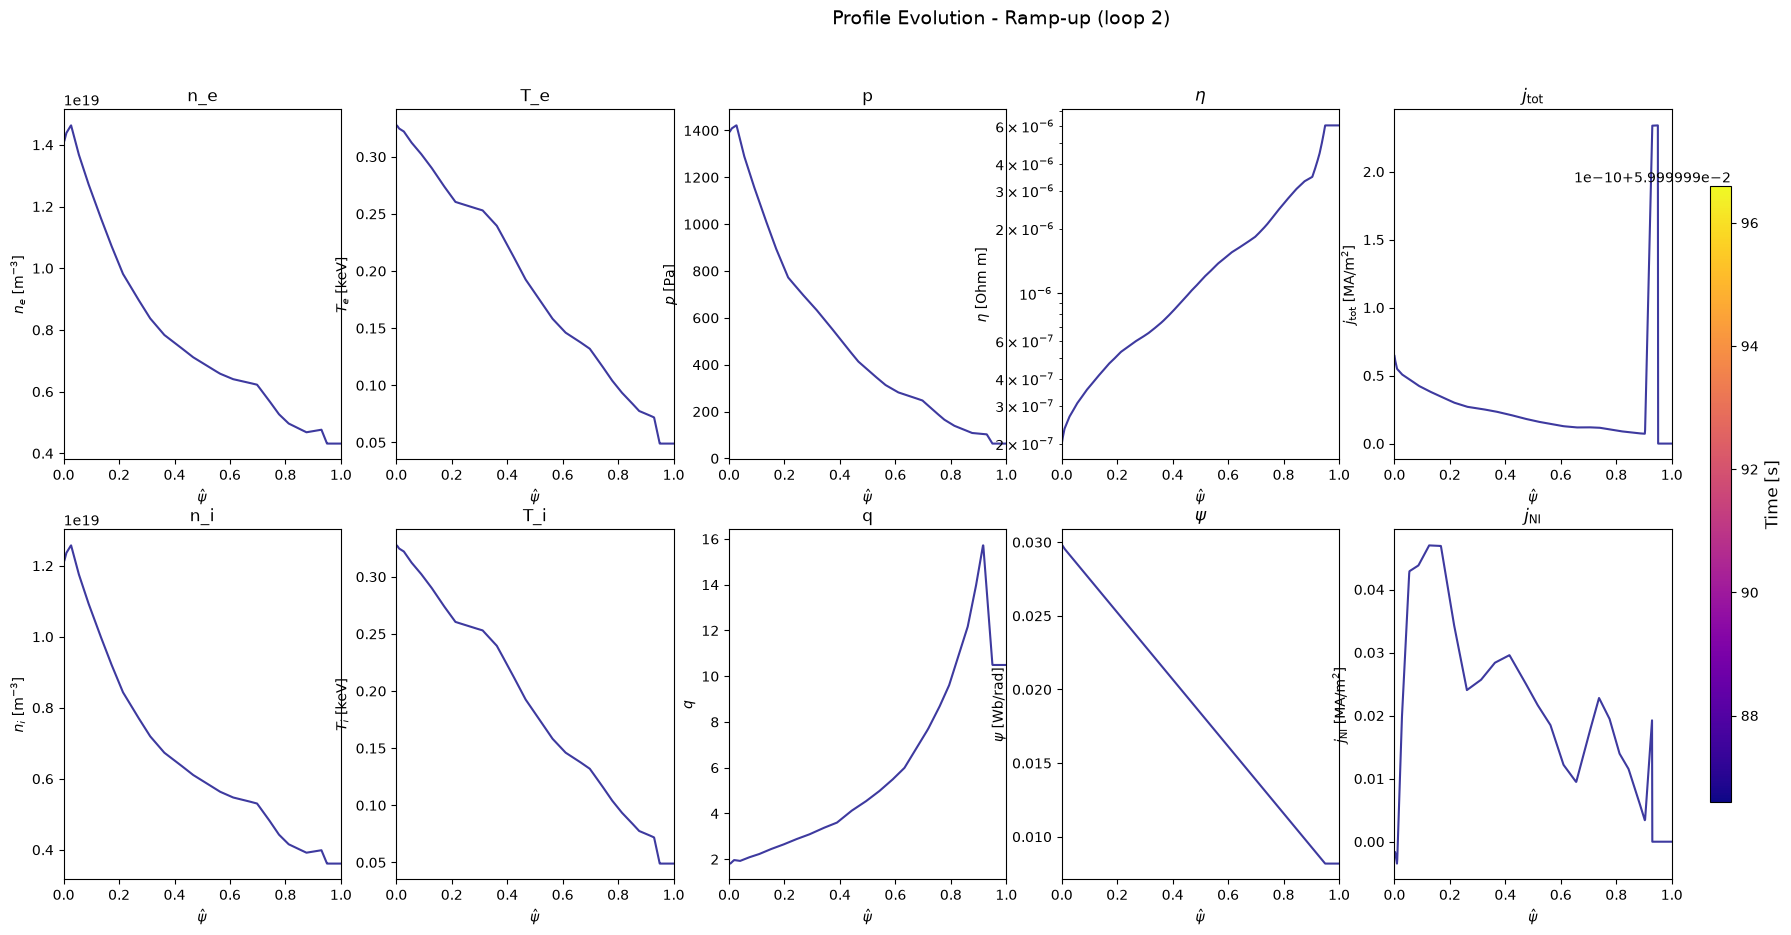

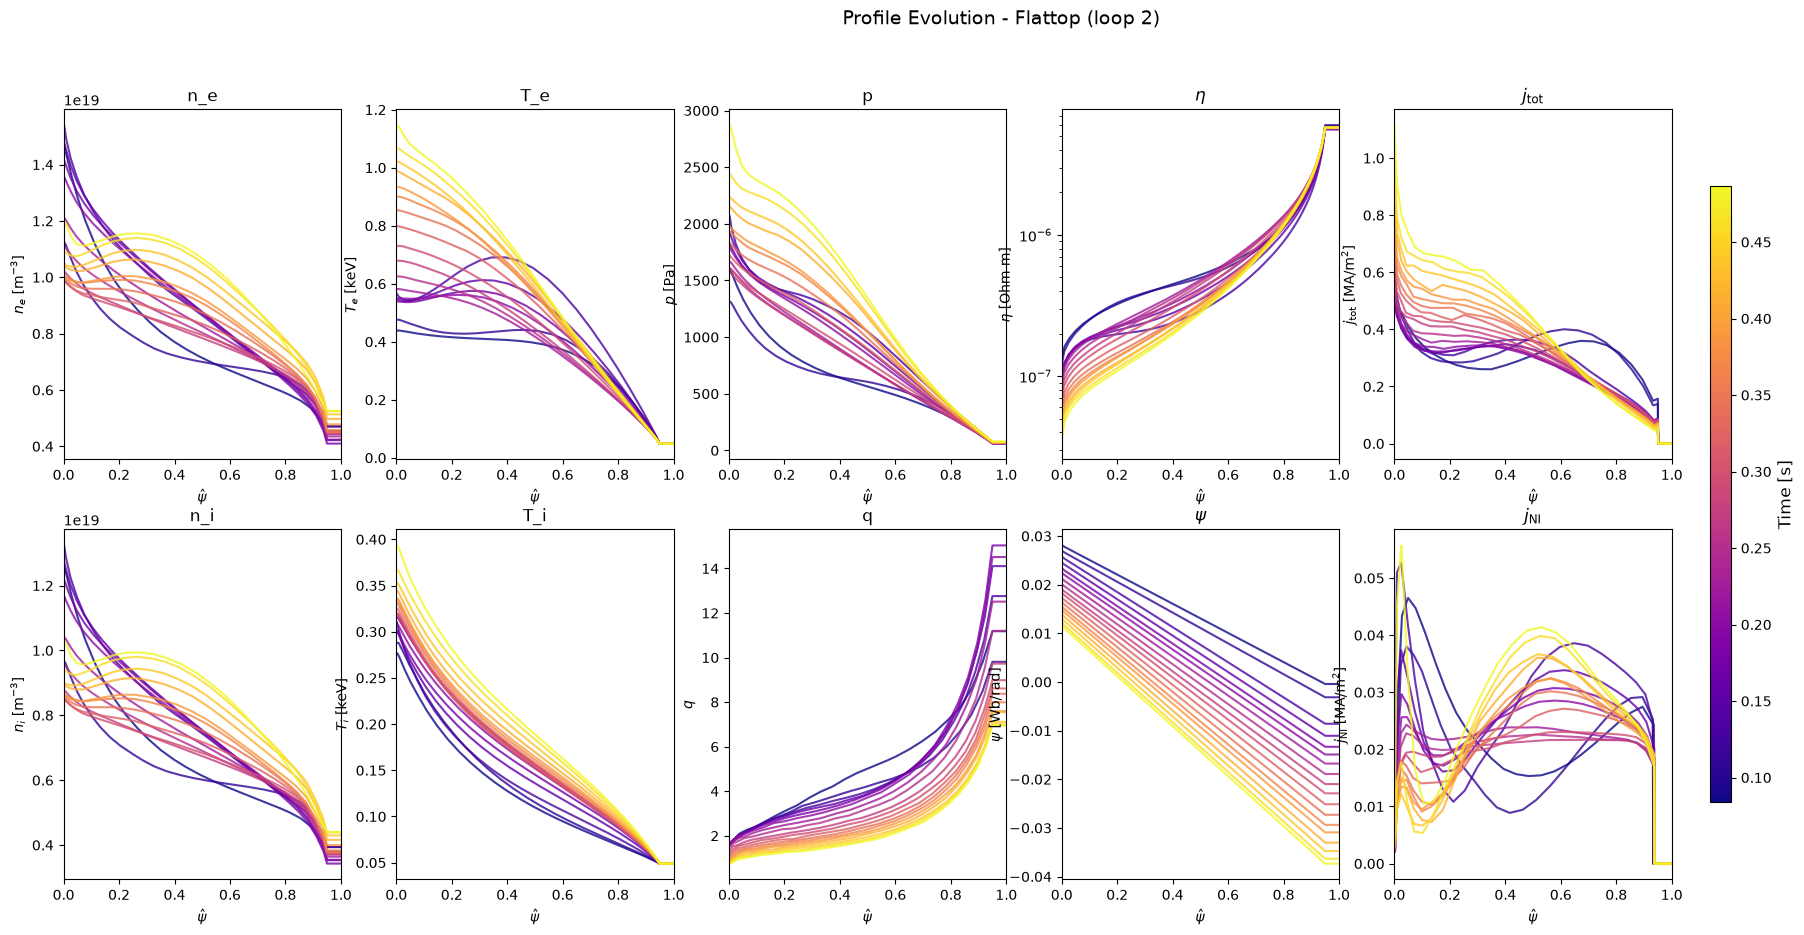

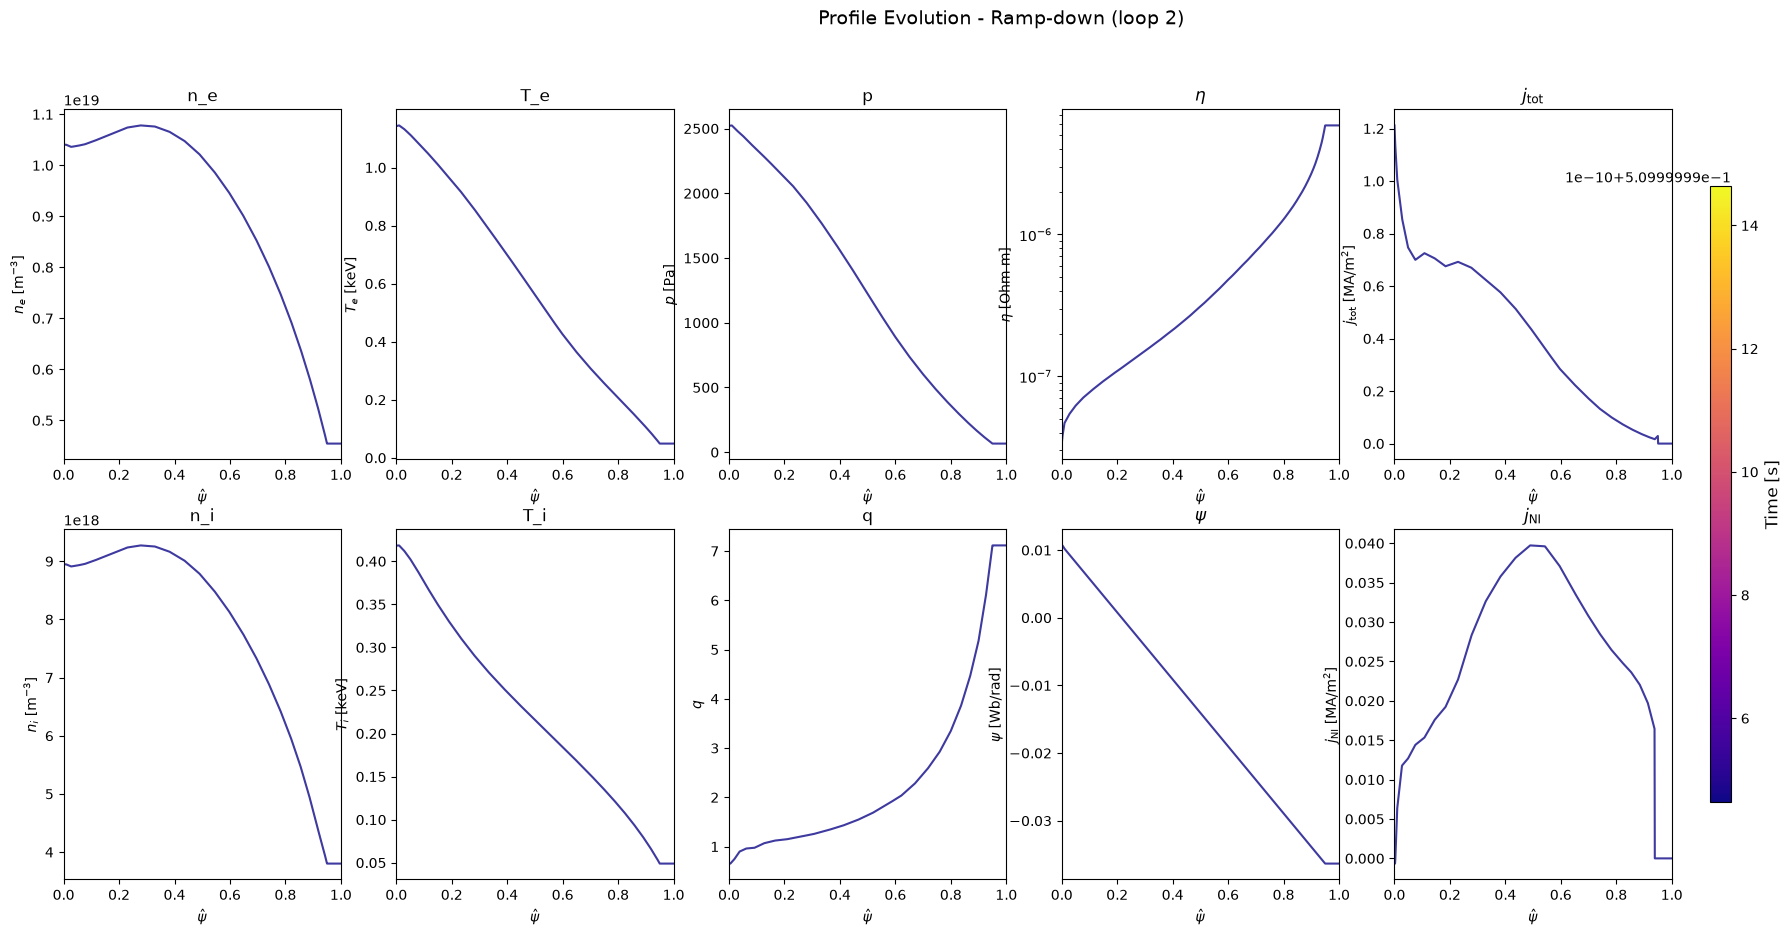

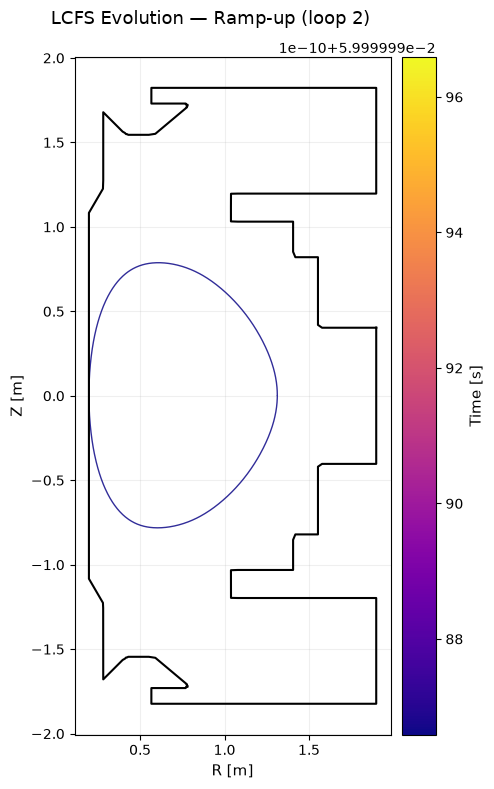

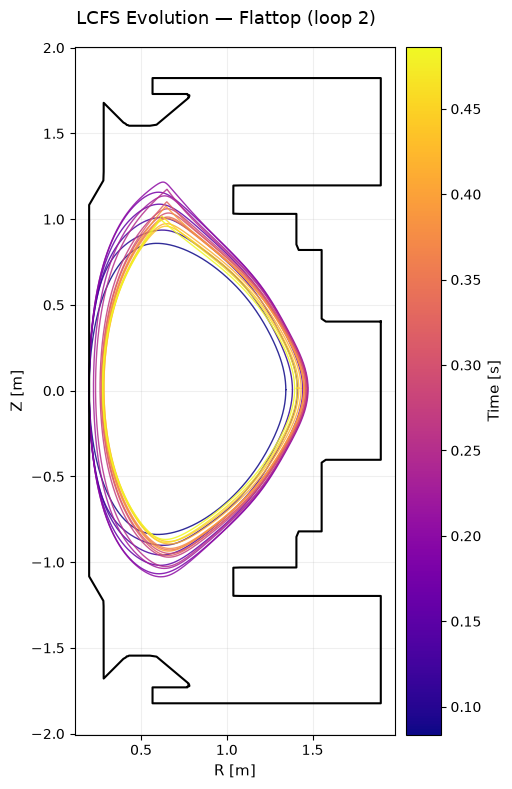

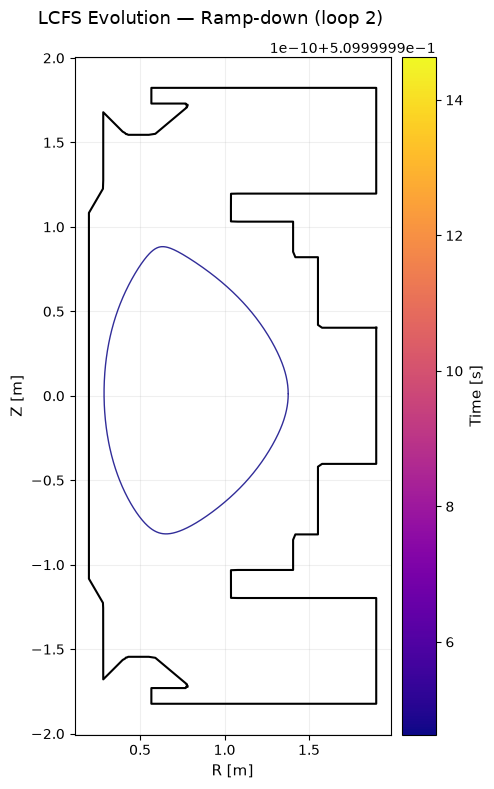

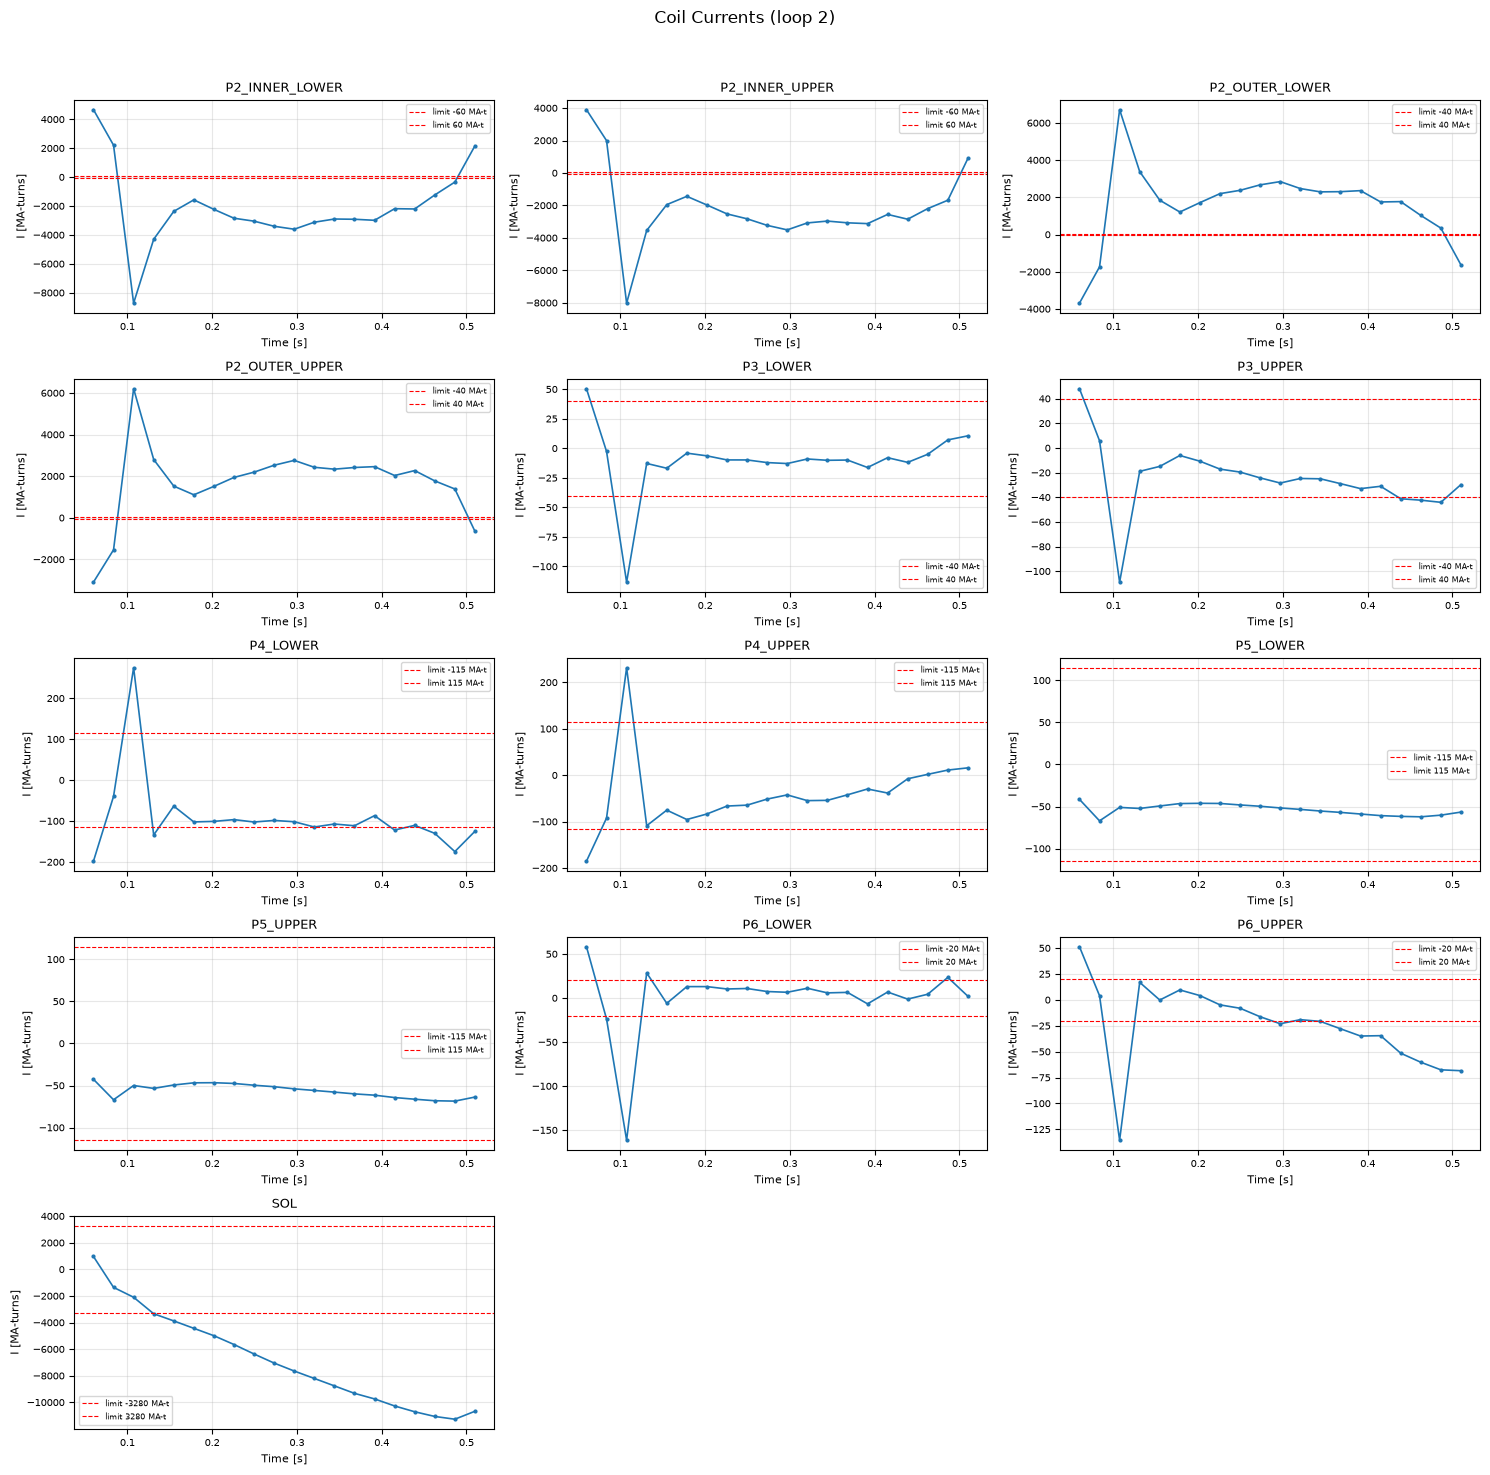

In [19]:
# Summary and plots from coupling object
tmtx.summary()
tmtx.plot_scalars()
tmtx.plot_profile_evolution()
tmtx.plot_lcfs_evolution()
tmtx.plot_coils()

EFIT (efm)              91 timestamps, median step 5.00 ms
core Thomson (ayc)     108 timestamps, median step 4.16 ms
TORAX output            91 timestamps
TokaMaker solves        20 timestamps
time [s]   rho    measured [keV]   simulated [keV]
  0.062   0.02         0.312            0.356
  0.104   0.02         0.452            0.474
  0.146   0.02         0.600            0.551
  0.187   0.02         0.678            0.542
  0.229   0.02         0.621            0.589
  0.271   0.03         0.618            0.666
  0.312   0.03         0.469            0.779
  0.354   0.03         0.495            0.872
  0.396   0.03         0.520            0.947
  0.437   0.03         0.589            1.015
  0.479   0.03         0.515            1.124


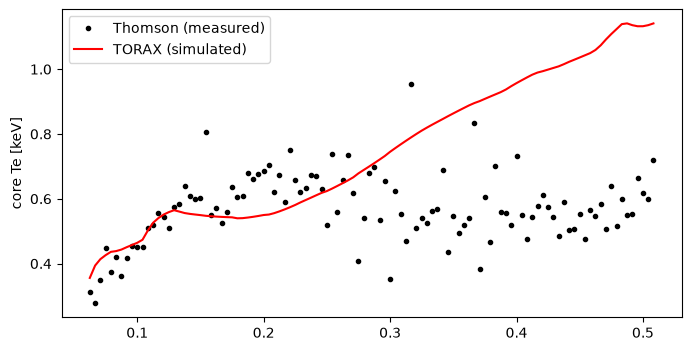

In [30]:
# Experimental timestamps inside simulated window
timeSources = {
    'EFIT (efm)': validTimes,
    'core Thomson (ayc)': thomsonValidTimes,
}

for label, times in timeSources.items():
    inWindow = times[(times >= tPulseStart) & (times <= tPulseEnd)]
    print(f'{label:20s} {len(inWindow):5d} timestamps, median step {1e3 * np.median(np.diff(inWindow)):.2f} ms')
txTimes = tmtx._data_tree.profiles.T_e.coords['time'].values
print(f'{"TORAX output":20s} {len(txTimes):5d} timestamps')
print(f'{"TokaMaker solves":20s} {len(tmtx.results["psi_lcfs_tm"]["x"]):5d} timestamps')

# Core Thomson Te at every measurement time from channel nearest to magnetic axis inside the LCFS
txTe = tmtx._data_tree.profiles.T_e

compareTimes = thomsonValidTimes[(thomsonValidTimes >= tPulseStart) & (thomsonValidTimes <= tPulseEnd)]
usedTimes, coreRho, teMeasured, teSimulated = [], [], [], []
for t in compareTimes:
    eq = efm.sel(time=t, method='nearest')
    thomsonNow = ayc.sel(time=t)
    r, te = thomsonNow['radius'].values, thomsonNow['te'].values
    valid = ~np.isnan(r) & ~np.isnan(te)
    rho = rhoTorNormFromPsiNorm(psiNormAtMidplane(r[valid], eq), eq, lastSurface)
    try:
        inside = np.where(rho < 1.0)[0]
        core = inside[np.argmin(rho[inside])]
    except ValueError:
        continue
    usedTimes.append(float(t))
    coreRho.append(rho[core])
    teMeasured.append(te[valid][core] / 1000.0)
    # TORAX Te at same time and rho interpolated from output grid
    teSimulated.append(float(txTe.interp(time=t, rho_norm=rho[core])))

usedTimes, coreRho = np.array(usedTimes), np.array(coreRho)
teMeasured, teSimulated = np.array(teMeasured), np.array(teSimulated)
print('time [s]   rho    measured [keV]   simulated [keV]')
for k in range(0, len(usedTimes), max(1, len(usedTimes) // 10)):
    print(f'{usedTimes[k]:7.3f}  {coreRho[k]:5.2f}  {teMeasured[k]:12.3f}  {teSimulated[k]:15.3f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(usedTimes, teMeasured, 'k.', label='Thomson (measured)')
ax.plot(usedTimes, teSimulated, 'r-', label='TORAX (simulated)')
ax.set_ylabel('core Te [keV]')
ax.legend()

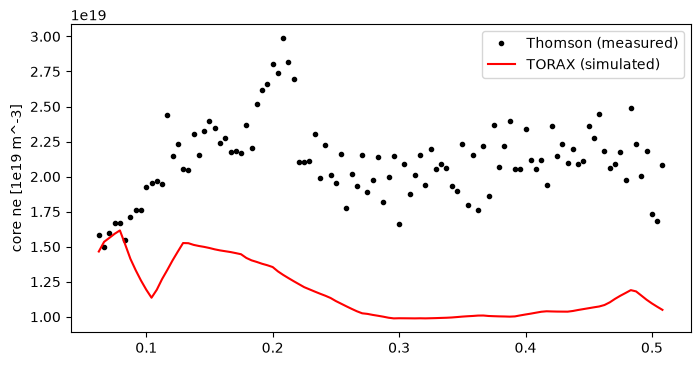

In [32]:
# Core Thomson ne at every measurement time from channel nearest magnetic axis inside the LCFS
txNe = tmtx._data_tree.profiles.n_e

neTimes, neMeasured, neSimulated = [], [], []
for t in compareTimes:
    eq = efm.sel(time=t, method='nearest')
    thomsonNow = ayc.sel(time=t)
    r, ne = thomsonNow['radius'].values, thomsonNow['ne'].values
    valid = ~np.isnan(r) & ~np.isnan(ne)
    rho = rhoTorNormFromPsiNorm(psiNormAtMidplane(r[valid], eq), eq, lastSurface)
    try:
        inside = np.where(rho < 1.0)[0]
        core = inside[np.argmin(rho[inside])]
    except ValueError:
        continue
    neTimes.append(float(t))
    neMeasured.append(ne[valid][core])
    neSimulated.append(float(txNe.interp(time=t, rho_norm=rho[core])))
neTimes, neMeasured, neSimulated = np.array(neTimes), np.array(neMeasured), np.array(neSimulated)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(neTimes, neMeasured, 'k.', label='Thomson (measured)')
ax.plot(neTimes, neSimulated, 'r-', label='TORAX (simulated)')
ax.set_ylabel('core ne [1e19 m^-3]')
ax.legend()